# Assignment 3: Recommender Systems

This notebook implements:
- TF-IDF based content recommendation
- User-profile based content recommendation
- User-based collaborative filtering
- Model-based collaborative filtering using SVD

## TF-IDF Based Content Recommender

In this task, we implement a content-based recommendation system using TF-IDF (Term Frequency–Inverse Document Frequency). 

Each movie is represented using its genres, which are treated as textual features. TF-IDF helps convert these textual features into numerical vectors by assigning importance to each term.

Movies with similar genre compositions will have similar TF-IDF vectors.

In [25]:
import pandas as pd
import numpy as np

In [26]:
movies = pd.read_csv("dataset/movies.csv")
ratings = pd.read_csv("dataset/ratings.csv")

In [27]:
movies['genres'] = movies['genres'].str.replace('|', ' ')
movies = movies[['movieId','title','genres']]

## TF-IDF Vectorization

We convert movie genres into numerical vectors using TF-IDF.  
This representation allows us to compute similarity between movies based on genre features.

In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english')

tfidf_matrix = tfidf.fit_transform(movies['genres'])

print(tfidf_matrix.shape)

(9742, 23)


## Similarity Matrix Computation

We compute pairwise cosine similarity between all movie vectors to create a similarity matrix.
This matrix is used to find similar movies.

In [29]:
from sklearn.metrics.pairwise import cosine_similarity

cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

In [30]:
indices = pd.Series(movies.index, index=movies['title']).drop_duplicates()

## Generating Recommendations

We retrieve the most similar movies based on cosine similarity scores and return top-N results.

In [31]:
def recommend_movies(title, top_n=5):
    idx = indices[title]
    
    sim_scores = list(enumerate(cosine_sim[idx]))
    
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    
    sim_scores = sim_scores[1:top_n+1]
    
    movie_indices = [i[0] for i in sim_scores]
    
    return movies.iloc[movie_indices][['title']], sim_scores

In [32]:
recommend_movies("Toy Story (1995)")

(                                               title
 1706                                     Antz (1998)
 2355                              Toy Story 2 (1999)
 2809  Adventures of Rocky and Bullwinkle, The (2000)
 3000                Emperor's New Groove, The (2000)
 3568                           Monsters, Inc. (2001),
 [(1706, 1.0), (2355, 1.0), (2809, 1.0), (3000, 1.0), (3568, 1.0)])

## User Profile Based Content Recommender

In this task, we personalize recommendations by building a user profile.

Each user profile is constructed as a weighted combination of the TF-IDF vectors of movies they have rated. The weights are based on the ratings given by the user.

This approach ensures that movies rated higher contribute more to the user’s preference profile.

### Mathematical Formulation

The user profile vector is computed as:

$$
P_u = \frac{\sum_{m} r_{u,m} \cdot f_m}{\sum_{m} r_{u,m}}
$$

Where:
- $Pu$ = User profile vector
- $ru,m$ = Rating given by user u to movie m
- $fm$ = Feature vector of movie m

This method builds a user profile by combining features of movies rated by the user, weighted by their ratings.

In [ ]:
movie_data = pd.merge(ratings, movies, on='movieId')
movie_data.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure Animation Children Comedy Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy Romance
2,1,6,4.0,964982224,Heat (1995),Action Crime Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime Mystery Thriller


## Constructing User Profile

We construct a user profile by:
1. Selecting movies rated by the user
2. Extracting their TF-IDF vectors
3. Weighting them using user ratings
4. Computing a normalized weighted average

In [34]:
def build_user_profile(user_id):
    user_movies = movie_data[movie_data['userId'] == user_id]
    
    movie_indices = user_movies['movieId'].apply(
        lambda x: movies[movies['movieId'] == x].index[0]
    )
    
    user_tfidf = tfidf_matrix[movie_indices]
    
    ratings_weights = user_movies['rating'].values.reshape(-1,1)
    
    user_profile = np.sum(user_tfidf.multiply(ratings_weights), axis=0) / np.sum(ratings_weights)
    
    return np.asarray(user_profile)

## Generating Recommendations for a User

Once the user profile is created, we compute similarity between the user profile and all movie vectors using cosine similarity.

Movies are then ranked based on similarity scores.

In [35]:
def recommend_for_user(user_id, top_n=5):
    user_profile = build_user_profile(user_id)

    similarity = cosine_similarity(user_profile.reshape(1, -1), tfidf_matrix)

    rated_movie_ids = ratings[ratings['userId'] == user_id]['movieId'].values
    rated_indices = movies[movies['movieId'].isin(rated_movie_ids)].index.tolist()

    sim_scores = list(enumerate(similarity[0]))
    sim_scores = [x for x in sim_scores if x[0] not in rated_indices]
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    movie_indices = [i[0] for i in sim_scores[:top_n]]

    return movies.iloc[movie_indices][['title']]

In [36]:
recommend_for_user(1)

,title
8597,Dragonheart 2: A New Beginning (2000)
6570,"Hunting Party, The (2007)"
4005,Flashback (1990)
4681,The Great Train Robbery (1978)
4409,Charlie's Angels: Full Throttle (2003)


## Evaluating Content-Based Filtering — Precision@K and Recall@K

We evaluate both the TF-IDF item-item recommender and the user-profile recommender using **Precision@K** and **Recall@K**.

- **Precision@K**: fraction of top-K recommendations that are relevant (rated ≥ 4).
- **Recall@K**: fraction of all relevant movies that appear in the top-K recommendations.

We use a per-user hold-out strategy: for each user, 20% of their highly-rated movies are held out as ground truth.

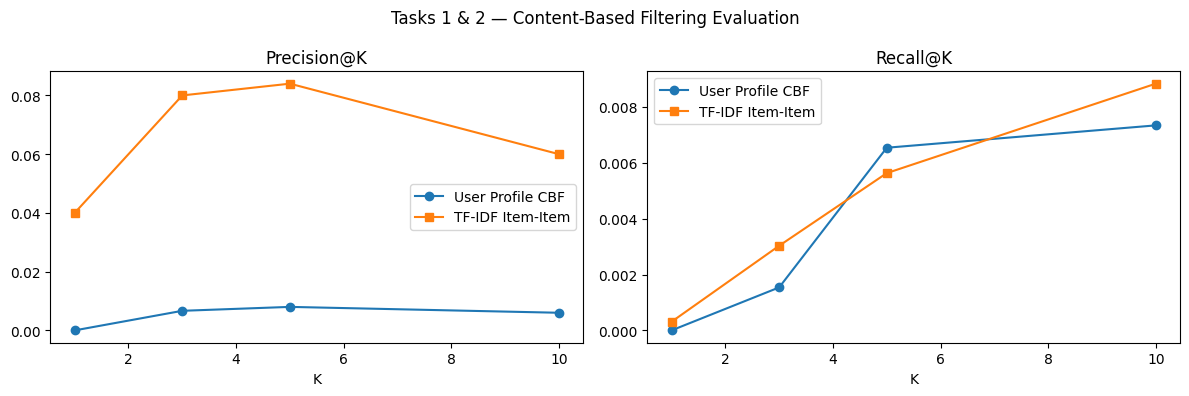

Task 1 — TF-IDF    | Precision@5: 0.0840 | Recall@5: 0.0056
Task 2 — UserProf  | Precision@5: 0.0080   | Recall@5: 0.0065


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split as sk_split
from sklearn.metrics.pairwise import cosine_similarity as cos_sim
import matplotlib.pyplot as plt

def evaluate_user_profile_recommender(ratings, movies, tfidf_matrix, k=5, threshold=4.0, n_users=50):
    sample_users = ratings['userId'].unique()[:n_users]
    precisions, recalls = [], []

    for uid in sample_users:
        user_ratings = ratings[ratings['userId'] == uid]
        relevant = user_ratings[user_ratings['rating'] >= threshold]
        if len(relevant) < 3:
            continue

        train_rel, test_rel = sk_split(relevant, test_size=0.2, random_state=42)
        train_ids = set(train_rel['movieId'].values)
        test_ids  = set(test_rel['movieId'].values)

        train_rows = user_ratings[user_ratings['movieId'].isin(train_ids)]
        movie_indices_list = [movies[movies['movieId'] == mid].index[0]
                              for mid in train_rows['movieId'].values
                              if not movies[movies['movieId'] == mid].empty]
        if not movie_indices_list:
            continue

        user_tfidf = tfidf_matrix[movie_indices_list]
        weights    = train_rows['rating'].values.reshape(-1, 1)
        user_profile = np.asarray(np.sum(user_tfidf.multiply(weights), axis=0) / np.sum(weights))

        similarity   = cos_sim(user_profile.reshape(1, -1), tfidf_matrix)[0]
        train_indices = movies[movies['movieId'].isin(train_ids)].index.tolist()
        sim_scores   = sorted([(i, s) for i, s in enumerate(similarity) if i not in train_indices],
                              key=lambda x: x[1], reverse=True)

        top_k_ids = set(movies.iloc[[i for i, _ in sim_scores[:k]]]['movieId'].values)
        hits = len(top_k_ids & test_ids)
        precisions.append(hits / k)
        recalls.append(hits / len(test_ids))

    return np.mean(precisions), np.mean(recalls)


def evaluate_tfidf_item_recommender(movies, cosine_sim, ratings, k=5, threshold=4.0, n_users=50):
    sample_users = ratings['userId'].unique()[:n_users]
    precisions, recalls = [], []

    for uid in sample_users:
        liked = ratings[(ratings['userId'] == uid) & (ratings['rating'] >= threshold)]
        if len(liked) < 3:
            continue

        seed_movie_id   = liked.iloc[0]['movieId']
        ground_truth_ids = set(liked.iloc[1:]['movieId'].values)

        seed_rows = movies[movies['movieId'] == seed_movie_id]
        if seed_rows.empty:
            continue
        idx = seed_rows.index[0]

        sim_scores = sorted(list(enumerate(cosine_sim[idx])), key=lambda x: x[1], reverse=True)[1:k+1]
        top_k_ids  = set(movies.iloc[[i for i, _ in sim_scores]]['movieId'].values)

        hits = len(top_k_ids & ground_truth_ids)
        precisions.append(hits / k)
        recalls.append(hits / len(ground_truth_ids))

    return np.mean(precisions), np.mean(recalls)


k_values = [1, 3, 5, 10]
prec_cbf, rec_cbf, prec_tfidf, rec_tfidf = [], [], [], []

for k in k_values:
    p,  r  = evaluate_user_profile_recommender(ratings, movies, tfidf_matrix, k=k)
    p1, r1 = evaluate_tfidf_item_recommender(movies, cosine_sim, ratings, k=k)
    prec_cbf.append(p);   rec_cbf.append(r)
    prec_tfidf.append(p1); rec_tfidf.append(r1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(k_values, prec_cbf,   marker='o', label='User Profile CBF')
axes[0].plot(k_values, prec_tfidf, marker='s', label='TF-IDF Item-Item')
axes[0].set_title('Precision@K'); axes[0].set_xlabel('K'); axes[0].legend()

axes[1].plot(k_values, rec_cbf,   marker='o', label='User Profile CBF')
axes[1].plot(k_values, rec_tfidf, marker='s', label='TF-IDF Item-Item')
axes[1].set_title('Recall@K'); axes[1].set_xlabel('K'); axes[1].legend()

plt.suptitle('Tasks 1 & 2 — Content-Based Filtering Evaluation')
plt.tight_layout(); plt.show()

print(f"Task 1 — TF-IDF    | Precision@5: {prec_tfidf[2]:.4f} | Recall@5: {rec_tfidf[2]:.4f}")
print(f"Task 2 — UserProf  | Precision@5: {prec_cbf[2]:.4f}   | Recall@5: {rec_cbf[2]:.4f}")

K= 1 | Precision@K: 0.0000 | Recall@K: 0.0000
K= 3 | Precision@K: 0.0067 | Recall@K: 0.0015
K= 5 | Precision@K: 0.0080 | Recall@K: 0.0065
K=10 | Precision@K: 0.0060 | Recall@K: 0.0073


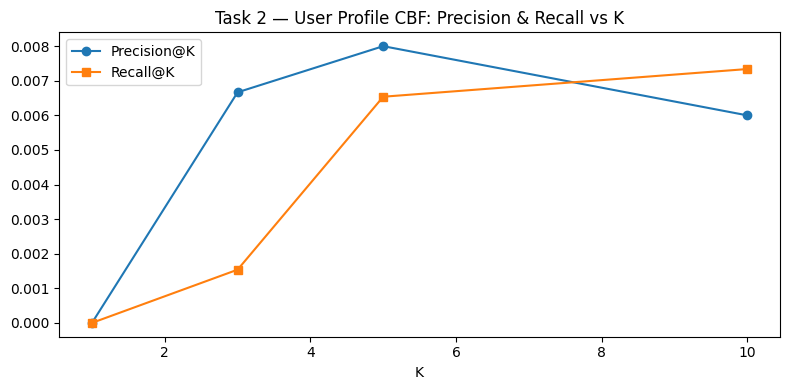

In [50]:
import numpy as np
from sklearn.model_selection import train_test_split as sk_split
from sklearn.metrics.pairwise import cosine_similarity as cos_sim

def evaluate_user_profile_cbf(ratings, movies, tfidf_matrix, k=5, threshold=4.0, n_users=50):
    sample_users = ratings['userId'].unique()[:n_users]
    precisions, recalls = [], []

    for uid in sample_users:
        user_ratings = ratings[ratings['userId'] == uid]
        relevant = user_ratings[user_ratings['rating'] >= threshold]
        if len(relevant) < 3:
            continue

        # Hold out 20% of liked movies as ground truth
        train_rel, test_rel = sk_split(relevant, test_size=0.2, random_state=42)
        train_ids = set(train_rel['movieId'].values)
        test_ids  = set(test_rel['movieId'].values)

        # Build profile from training portion only
        train_rows = user_ratings[user_ratings['movieId'].isin(train_ids)]
        idxs = [movies[movies['movieId'] == m].index[0]
                for m in train_rows['movieId'].values
                if not movies[movies['movieId'] == m].empty]
        if not idxs:
            continue

        user_tfidf  = tfidf_matrix[idxs]
        weights     = train_rows['rating'].values.reshape(-1, 1)
        user_profile = np.asarray(np.sum(user_tfidf.multiply(weights), axis=0) / np.sum(weights))

        similarity    = cos_sim(user_profile.reshape(1, -1), tfidf_matrix)[0]
        train_indices = movies[movies['movieId'].isin(train_ids)].index.tolist()

        # Only exclude training movies — test movies stay visible
        sim_scores = sorted([(i, s) for i, s in enumerate(similarity)
                              if i not in train_indices], key=lambda x: x[1], reverse=True)

        top_k_ids = set(movies.iloc[[i for i, _ in sim_scores[:k]]]['movieId'].values)
        hits = len(top_k_ids & test_ids)
        precisions.append(hits / k)
        recalls.append(hits / len(test_ids))

    return np.mean(precisions), np.mean(recalls)

# Evaluate across K values
import matplotlib.pyplot as plt
k_values = [1, 3, 5, 10]
prec_list, rec_list = [], []

for k in k_values:
    p, r = evaluate_user_profile_cbf(ratings, movies, tfidf_matrix, k=k)
    prec_list.append(p); rec_list.append(r)
    print(f"K={k:>2} | Precision@K: {p:.4f} | Recall@K: {r:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(k_values, prec_list, marker='o', label='Precision@K')
plt.plot(k_values, rec_list,  marker='s', label='Recall@K')
plt.title('Task 2 — User Profile CBF: Precision & Recall vs K')
plt.xlabel('K'); plt.legend(); plt.tight_layout(); plt.show()

In [38]:
def evaluate_tfidf_item_recommender(movies, cosine_sim, ratings,
                                    k=5, threshold=4.0, n_users=50, seed=42):
    np.random.seed(seed)
    sample_users = ratings['userId'].unique()[:n_users]
    precisions, recalls = [], []

    for uid in sample_users:
        liked = ratings[(ratings['userId'] == uid) & (ratings['rating'] >= threshold)]
        if len(liked) < 3:
            continue

        # Seed = first liked movie, ground truth = rest of liked movies
        seed_movie_id = liked.iloc[0]['movieId']
        ground_truth_ids = set(liked.iloc[1:]['movieId'].values)

        seed_rows = movies[movies['movieId'] == seed_movie_id]
        if seed_rows.empty:
            continue
        idx = seed_rows.index[0]

        sim_scores = sorted(list(enumerate(cosine_sim[idx])), key=lambda x: x[1], reverse=True)
        sim_scores = sim_scores[1:k+1]  # Skip self

        top_k_movie_ids = set(movies.iloc[[i for i, _ in sim_scores]]['movieId'].values)

        hits = len(top_k_movie_ids & ground_truth_ids)
        precisions.append(hits / k)
        recalls.append(hits / len(ground_truth_ids))

    return np.mean(precisions), np.mean(recalls)

p1, r1 = evaluate_tfidf_item_recommender(movies, cosine_sim, ratings, k=5)
print(f"Task 1 — TF-IDF Item-Item  | Precision@5: {p1:.4f} | Recall@5: {r1:.4f}")


Task 1 — TF-IDF Item-Item  | Precision@5: 0.0840 | Recall@5: 0.0056


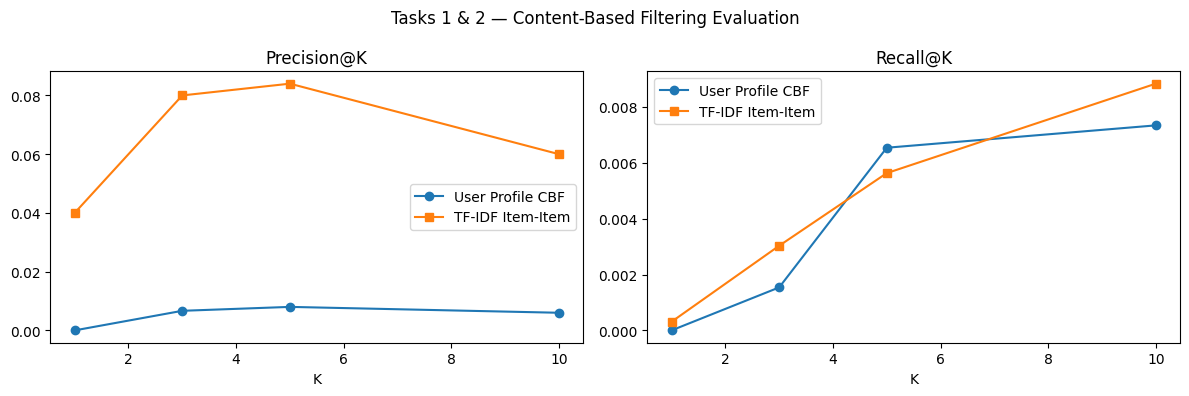


Summary Table:
K     Prec(UserProfile)      Rec(UserProfile)     Prec(TF-IDF)       Rec(TF-IDF)
1     0.0000                 0.0000               0.0400             0.0003
3     0.0067                 0.0015               0.0800             0.0030
5     0.0080                 0.0065               0.0840             0.0056
10    0.0060                 0.0073               0.0600             0.0088


In [39]:
import matplotlib.pyplot as plt

k_values = [1, 3, 5, 10]
prec_cbf, rec_cbf = [], []
prec_tfidf, rec_tfidf = [], []

for k in k_values:
    p, r   = evaluate_user_profile_recommender(ratings, movies, tfidf_matrix, k=k)
    p1, r1 = evaluate_tfidf_item_recommender(movies, cosine_sim, ratings, k=k)
    prec_cbf.append(p);   rec_cbf.append(r)
    prec_tfidf.append(p1); rec_tfidf.append(r1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(k_values, prec_cbf,   marker='o', label='User Profile CBF')
axes[0].plot(k_values, prec_tfidf, marker='s', label='TF-IDF Item-Item')
axes[0].set_title('Precision@K'); axes[0].set_xlabel('K'); axes[0].legend()

axes[1].plot(k_values, rec_cbf,   marker='o', label='User Profile CBF')
axes[1].plot(k_values, rec_tfidf, marker='s', label='TF-IDF Item-Item')
axes[1].set_title('Recall@K'); axes[1].set_xlabel('K'); axes[1].legend()

plt.suptitle('Tasks 1 & 2 — Content-Based Filtering Evaluation')
plt.tight_layout(); plt.show()

print("\nSummary Table:")
print(f"{'K':<5} {'Prec(UserProfile)':<22} {'Rec(UserProfile)':<20} {'Prec(TF-IDF)':<18} {'Rec(TF-IDF)'}")
for k, p, r, p1, r1 in zip(k_values, prec_cbf, rec_cbf, prec_tfidf, rec_tfidf):
    print(f"{k:<5} {p:<22.4f} {r:<20.4f} {p1:<18.4f} {r1:.4f}")


## User-Based Collaborative Filtering

In this task, we implement collaborative filtering using user-user similarity.

Unlike content-based filtering, this approach recommends movies based on similar users' preferences.

If two users have rated movies similarly in the past, they are considered similar, and their preferences can be used to recommend new movies.

### Mathematical Formulation

The predicted rating is computed as:

$$
r(u, i) = \frac{\sum_{v \in U} \text{sim}(u, v) \cdot r(v, i)}{\sum_{v \in U} |\text{sim}(u, v)|}
$$

Where:
- $r(u, i)$ = predicted rating of user u for item i
- $sim(u, v)$ = similarity between users u and v
- $r(v, i)$ = rating given by user v to item i

This method predicts ratings using preferences of similar users, making it a collaborative approach.

In [40]:
from surprise import Dataset, Reader

reader = Reader(rating_scale=(0.5, 5.0))

data = Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader)

## Train-Test Split

We split the dataset into training and testing sets to evaluate model performance.

In [41]:
from surprise import KNNBasic
from surprise.model_selection import train_test_split

trainset, testset = train_test_split(data, test_size=0.2)

sim_options = {
    'name': 'cosine',
    'user_based': True
}

model = KNNBasic(sim_options=sim_options)
model.fit(trainset)

Computing the cosine similarity matrix...
Done computing similarity matrix.


## Model Evaluation

We evaluate the model using RMSE (Root Mean Square Error).

In [42]:
from surprise import accuracy

predictions = model.test(testset)

rmse = accuracy.rmse(predictions)
print("RMSE:", rmse)

RMSE: 0.9823
RMSE: 0.9822558142846856


## Generating Recommendations

We predict ratings for unseen movies and recommend top-rated ones.

In [43]:
def recommend_cf(user_id, top_n=5):
    all_movies = ratings['movieId'].unique()
    
    rated_movies = ratings[ratings['userId'] == user_id]['movieId'].values
    
    unseen_movies = [m for m in all_movies if m not in rated_movies]
    
    predictions = []
    
    for movie_id in unseen_movies:
        pred = model.predict(user_id, movie_id)
        predictions.append((movie_id, pred.est))
    
    predictions = sorted(predictions, key=lambda x: x[1], reverse=True)
    
    top_movies = predictions[:top_n]
    
    movie_titles = [movies[movies['movieId'] == m[0]]['title'].values[0] for m in top_movies]
    
    return movie_titles

In [44]:
recommend_cf(1)

["I'm the One That I Want (2000)",
 'Hunger (2008)',
 'Midnight Clear, A (1992)',
 'Hard Core Logo (1996)',
 'Safety Last! (1923)']

Computing the pearson similarity matrix...
Done computing similarity matrix.
RMSE: 0.9829
User-Based CF (Pearson) RMSE: 0.9829472991774267
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
K= 10 | Cosine RMSE: 0.9962 | Pearson RMSE: 0.9959
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
K= 20 | Cosine RMSE: 0.9847 | Pearson RMSE: 0.9858
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
K= 40 | Cosine RMSE: 0.9823 | Pearson RMSE: 0.9829
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
K= 60 | Cosine RMSE: 0.9824 | Pearson RMSE: 0.9829


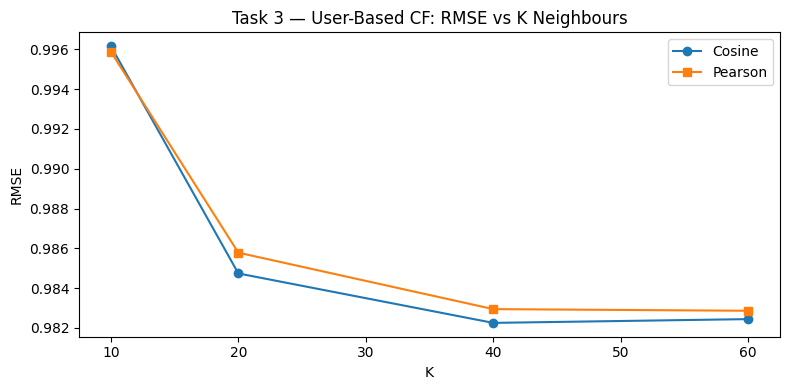


User-Based CF (Pearson) | Precision@5: 0.4748 | Recall@5: 0.2508
User-Based CF (Cosine)  | Precision@5: 0.4977 | Recall@5: 0.2617


In [51]:
from surprise import KNNBasic
from surprise.model_selection import cross_validate
from collections import defaultdict

# ── 1. Pearson Correlation (better than cosine when users have rating bias) ────
sim_options_pearson = {'name': 'pearson', 'user_based': True}
model_pearson = KNNBasic(k=40, sim_options=sim_options_pearson)
model_pearson.fit(trainset)
preds_pearson = model_pearson.test(testset)
print("User-Based CF (Pearson) RMSE:", accuracy.rmse(preds_pearson))

# ── 2. Test different K values ─────────────────────────────────────────────────
k_values = [10, 20, 40, 60]
rmse_cosine, rmse_pearson = [], []

for k in k_values:
    m1 = KNNBasic(k=k, sim_options={'name': 'cosine',  'user_based': True})
    m2 = KNNBasic(k=k, sim_options={'name': 'pearson', 'user_based': True})
    m1.fit(trainset); m2.fit(trainset)
    rmse_cosine.append(accuracy.rmse(m1.test(testset),  verbose=False))
    rmse_pearson.append(accuracy.rmse(m2.test(testset), verbose=False))
    print(f"K={k:>3} | Cosine RMSE: {rmse_cosine[-1]:.4f} | Pearson RMSE: {rmse_pearson[-1]:.4f}")

import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
plt.plot(k_values, rmse_cosine,  marker='o', label='Cosine')
plt.plot(k_values, rmse_pearson, marker='s', label='Pearson')
plt.title('Task 3 — User-Based CF: RMSE vs K Neighbours')
plt.xlabel('K'); plt.ylabel('RMSE'); plt.legend(); plt.tight_layout(); plt.show()

# ── 3. Precision@K and Recall@K ────────────────────────────────────────────────
def precision_recall_at_k(predictions, k=5, threshold=4.0):
    user_est_true = defaultdict(list)
    for uid, _, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))

    precisions, recalls = {}, {}
    for uid, user_ratings in user_est_true.items():
        user_ratings.sort(key=lambda x: x[0], reverse=True)
        n_rel       = sum(1 for (_, true_r) in user_ratings if true_r >= threshold)
        n_rec_k     = sum(1 for (est, _)    in user_ratings[:k] if est   >= threshold)
        n_rel_and_rec_k = sum(1 for (est, true_r) in user_ratings[:k]
                              if est >= threshold and true_r >= threshold)
        precisions[uid] = n_rel_and_rec_k / k          if k else 0
        recalls[uid]    = n_rel_and_rec_k / n_rel      if n_rel else 0

    return sum(precisions.values()) / len(precisions), sum(recalls.values()) / len(recalls)

p, r = precision_recall_at_k(preds_pearson, k=5)
print(f"\nUser-Based CF (Pearson) | Precision@5: {p:.4f} | Recall@5: {r:.4f}")

p2, r2 = precision_recall_at_k(model.test(testset), k=5)
print(f"User-Based CF (Cosine)  | Precision@5: {p2:.4f} | Recall@5: {r2:.4f}")

## Model-Based Collaborative Filtering (SVD)

In this task, we implement model-based collaborative filtering using Singular Value Decomposition (SVD).

Unlike memory-based methods, SVD learns latent features for users and items, capturing hidden patterns in user-item interactions.

This approach improves recommendation accuracy by reducing dimensionality and handling sparsity effectively.

### Mathematical Formulation

The predicted rating is given by:

$$
r(u, i) = \mu + b_u + b_i + q_i^T p_u
$$

Where:
- $\mu$ = global average rating  
- $b_u$ = user bias  
- $b_i$ = item bias  
- $p_u$ = user latent vector  
- $q_i$ = item latent vector  

In [45]:
from surprise import SVD

svd_model = SVD()
svd_model.fit(trainset)

## Model Evaluation

We evaluate the SVD model using RMSE to measure prediction accuracy.

In [46]:
predictions_svd = svd_model.test(testset)

from surprise import accuracy
print("RMSE:", accuracy.rmse(predictions_svd))

RMSE: 0.8808
RMSE: 0.8807629029948347


## Generating Recommendations

We use the trained SVD model to predict ratings for unseen movies and recommend the highest predicted ones.

In [47]:
def recommend_svd(user_id, top_n=5):
    all_movies = ratings['movieId'].unique()
    
    rated_movies = ratings[ratings['userId'] == user_id]['movieId'].values
    
    unseen_movies = [m for m in all_movies if m not in rated_movies]
    
    predictions = []
    
    for movie_id in unseen_movies:
        pred = svd_model.predict(user_id, movie_id)
        predictions.append((movie_id, pred.est))
    
    predictions = sorted(predictions, key=lambda x: x[1], reverse=True)
    
    top_movies = predictions[:top_n]
    
    movie_titles = [movies[movies['movieId'] == m[0]]['title'].values[0] for m in top_movies]
    
    return movie_titles

In [48]:
recommend_svd(1)

['Shawshank Redemption, The (1994)',
 'Philadelphia Story, The (1940)',
 'Casablanca (1942)',
 'Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1964)',
 "One Flew Over the Cuckoo's Nest (1975)"]

## Task 4: Item-Based Collaborative Filtering

Item-Based CF recommends movies based on similarity between items rather than users.
The key idea: if two movies are rated similarly by many users, they are likely similar.

**Similarity Metric:** Pearson correlation — accounts for rating scale differences across users.

**Prediction formula:**

$$\hat{r}_{u,i} = \frac{\sum_{j \in N} sim(i,j) \cdot r_{u,j}}{\sum_{j \in N} |sim(i,j)|}$$

Where:
- $N$ = set of similar items the user has already rated
- $sim(i,j)$ = Pearson similarity between items i and j
- $r_{u,j}$ = user's rating for item j

In [ ]:
from surprise import KNNBasic
from surprise import accuracy
from collections import defaultdict

# ── 1. Item-Based CF using Pearson correlation ─────────────────────────────────
sim_options_item = {'name': 'pearson', 'user_based': False}  # user_based=False → item-based
model_item = KNNBasic(k=40, sim_options=sim_options_item)
model_item.fit(trainset)

preds_item = model_item.test(testset)
print("Item-Based CF (Pearson) RMSE:", accuracy.rmse(preds_item))

# ── 2. Test different K values ─────────────────────────────────────────────────
k_values = [10, 20, 40, 60]
rmse_item, rmse_user = [], []

for k in k_values:
    m_item = KNNBasic(k=k, sim_options={'name': 'pearson', 'user_based': False})
    m_user = KNNBasic(k=k, sim_options={'name': 'pearson', 'user_based': True})
    m_item.fit(trainset); m_user.fit(trainset)
    rmse_item.append(accuracy.rmse(m_item.test(testset), verbose=False))
    rmse_user.append(accuracy.rmse(m_user.test(testset), verbose=False))
    print(f"K={k:>3} | Item RMSE: {rmse_item[-1]:.4f} | User RMSE: {rmse_user[-1]:.4f}")

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.plot(k_values, rmse_item, marker='o', label='Item-Based CF')
plt.plot(k_values, rmse_user, marker='s', label='User-Based CF')
plt.title('Task 4 — Item-Based vs User-Based CF: RMSE vs K')
plt.xlabel('K'); plt.ylabel('RMSE'); plt.legend(); plt.tight_layout(); plt.show()

# ── 3. Recommendation function ─────────────────────────────────────────────────
def recommend_item_cf(user_id, top_n=5):
    all_movies   = ratings['movieId'].unique()
    rated_movies = ratings[ratings['userId'] == user_id]['movieId'].values
    unseen       = [m for m in all_movies if m not in rated_movies]

    preds = [(m, model_item.predict(user_id, m).est) for m in unseen]
    preds.sort(key=lambda x: x[1], reverse=True)

    return [movies[movies['movieId'] == m]['title'].values[0] for m, _ in preds[:top_n]]

print("\nTop-5 recommendations for User 1 (Item-Based CF):")
print(recommend_item_cf(1))

# ── 4. Precision@K and Recall@K ────────────────────────────────────────────────
def precision_recall_at_k(predictions, k=5, threshold=4.0):
    user_est_true = defaultdict(list)
    for uid, _, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))
    precisions, recalls = [], []
    for user_ratings in user_est_true.values():
        user_ratings.sort(key=lambda x: x[0], reverse=True)
        top_k    = user_ratings[:k]
        n_rel    = sum(1 for (_, t) in user_ratings if t >= threshold)
        n_hits   = sum(1 for (e, t) in top_k if e >= threshold and t >= threshold)
        precisions.append(n_hits / k)
        recalls.append(n_hits / n_rel if n_rel else 0)
    return sum(precisions)/len(precisions), sum(recalls)/len(recalls)

p_item, r_item = precision_recall_at_k(preds_item, k=5)
p_user, r_user = precision_recall_at_k(preds_pearson, k=5)  # from Task 3

print(f"\nItem-Based CF | Precision@5: {p_item:.4f} | Recall@5: {r_item:.4f}")
print(f"User-Based CF | Precision@5: {p_user:.4f} | Recall@5: {r_user:.4f}")